In [1]:
#Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Step 2: Load Dataset

df1 = pd.read_csv('/content/Unemployment in India.csv')
df2 = pd.read_csv('/content/Unemployment_Rate_upto_11_2020.csv')

In [5]:
#Step 3: Check Dataset Information
df1.head()
df2.head()

print(df1.info())
print(df2.info())

print(df1.isnull().sum())
print(df2.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------             

In [7]:
#Step 4: Data Cleaning

# Remove spaces in column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Remove missing values
df1 = df1.dropna()
df2 = df2.dropna()

# Convert Date column to datetime
df1['Date'] = pd.to_datetime(df1['Date'])
df2['Date'] = pd.to_datetime(df2['Date'])

print("Data Cleaned Successfully")

Data Cleaned Successfully


/tmp/ipykernel_3462/3230761185.py:12: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['Date'] = pd.to_datetime(df1['Date'])
/tmp/ipykernel_3462/3230761185.py:13: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df2['Date'] = pd.to_datetime(df2['Date'])


In [9]:
#Step 5: Statistical Summary
df1.describe()

df1['Estimated Unemployment Rate (%)'].mean()

np.float64(11.787945945945946)

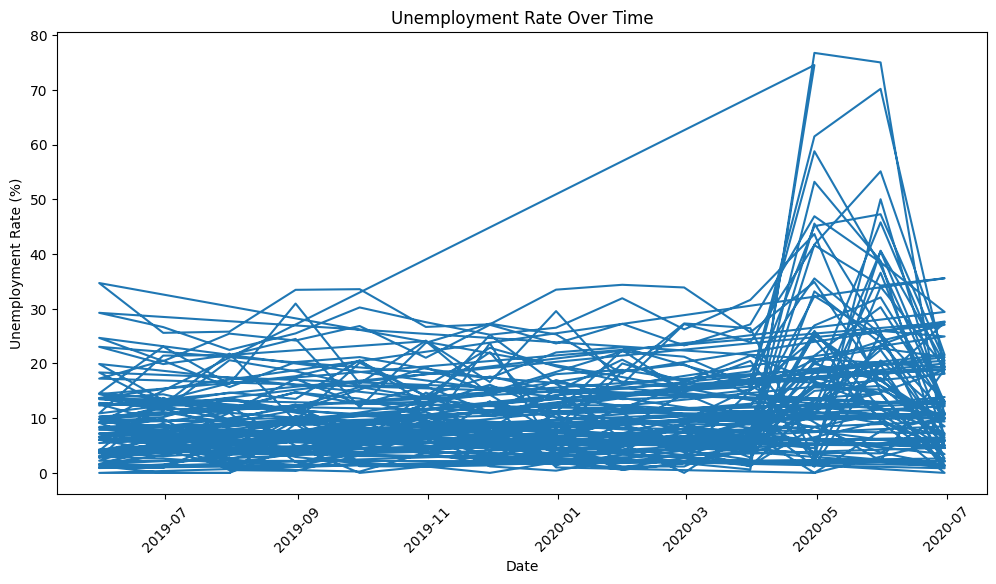

In [10]:
#Step 6: Unemployment Trend Analysis
plt.figure(figsize=(12,6))

plt.plot(
    df1['Date'],
    df1['Estimated Unemployment Rate (%)']
)

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [11]:
#Step 7: Covid-19 Impact Analysis

#Filter 2020 data:

covid_data = df1[df1['Date'].dt.year == 2020]

covid_data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
8,Andhra Pradesh,2020-01-31,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,2020-02-29,Monthly,5.91,11723617.0,42.83,Rural
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural


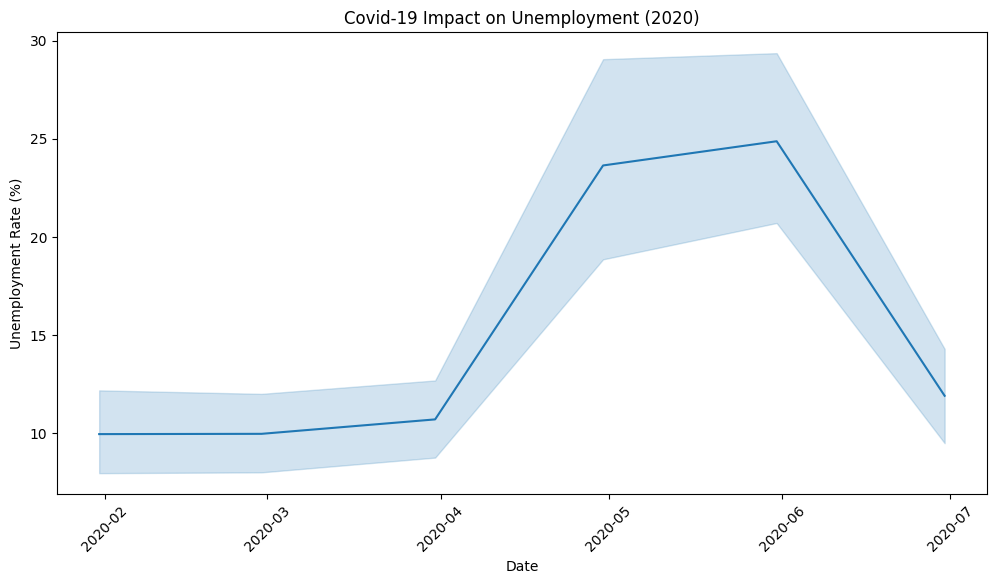

In [12]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=covid_data
)

plt.title('Covid-19 Impact on Unemployment (2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [13]:
#Step 8: State-wise Analysis

#Find states with highest unemployment:

state_data = df1.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

state_data

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


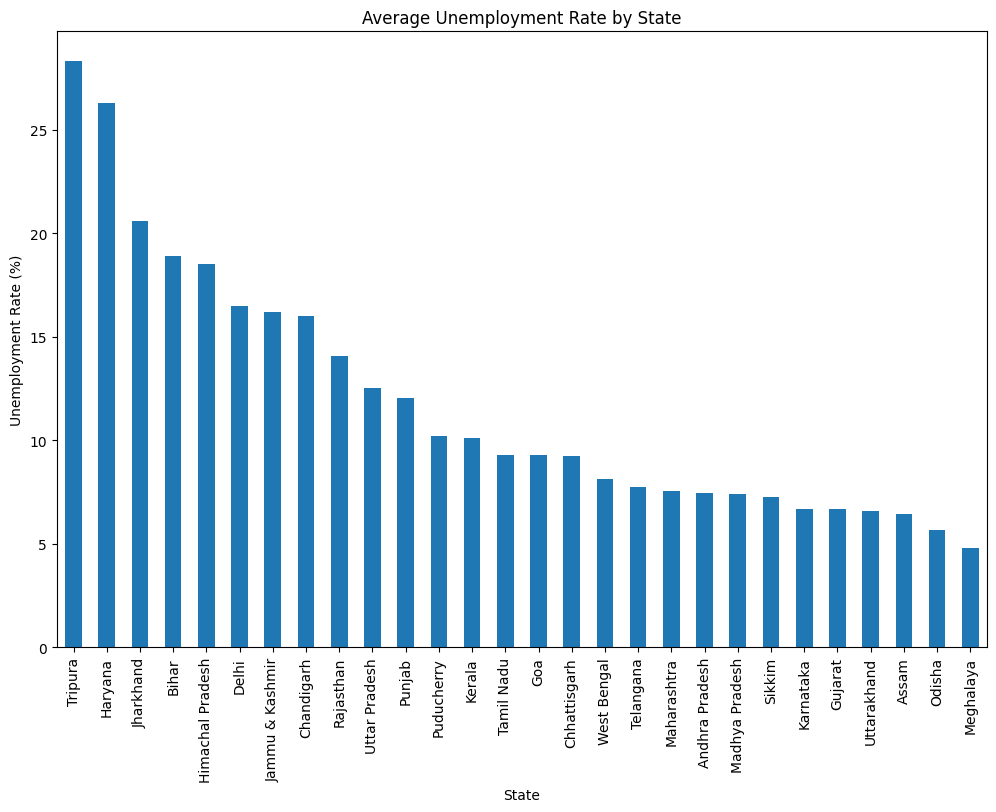

In [14]:
plt.figure(figsize=(12,8))

state_data.plot(kind='bar')

plt.title('Average Unemployment Rate by State')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')

plt.show()

In [15]:
#Step 12: Seasonal Trend Analysis

#Monthly unemployment trend:

df1['Month'] = df1['Date'].dt.month

monthly_trend = df1.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

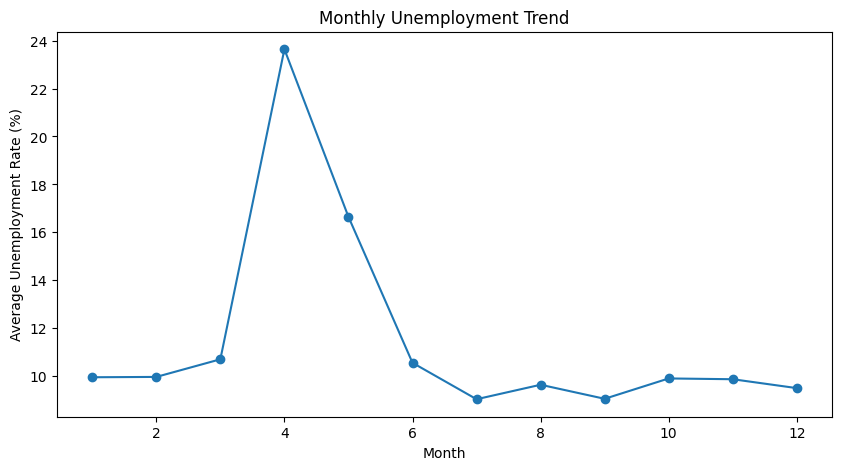

In [16]:
plt.figure(figsize=(10,5))

monthly_trend.plot(marker='o')

plt.title('Monthly Unemployment Trend')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

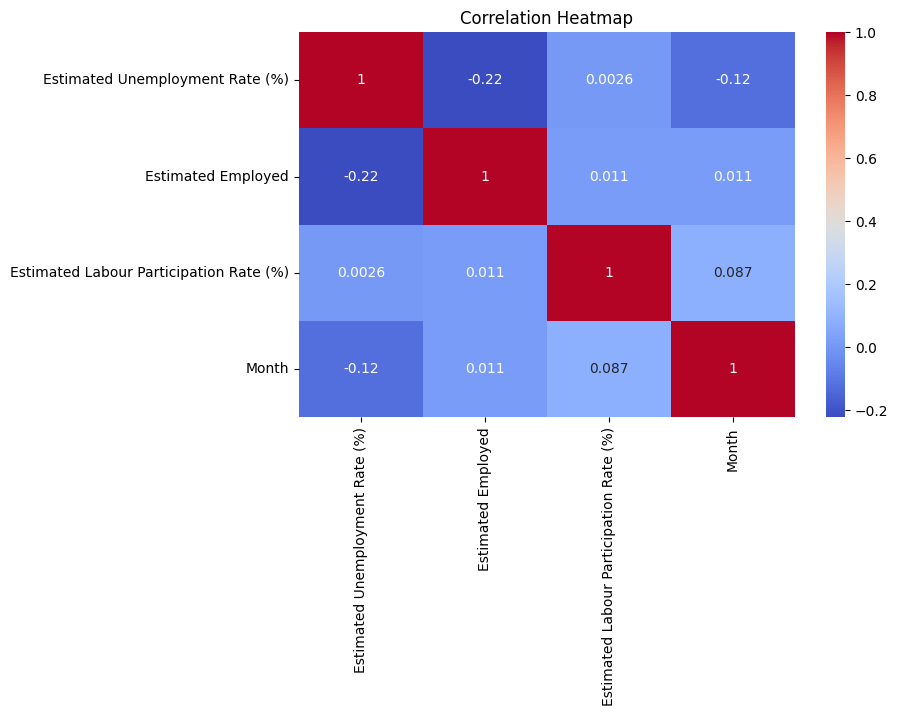

In [17]:
#Step 13: Correlation Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [18]:
"""
Conclusion:
Unemployment varied across Indian states.
Covid-19 had a major impact on unemployment in 2020.
Lockdown periods caused unemployment spikes.
Some regions showed consistently higher unemployment rates.
Monthly analysis revealed seasonal employment variations.

Recommendations:
Increase employment programs.
Promote skill development.
Improve economic recovery policies after crises.

"""

'\nConclusion:\nUnemployment varied across Indian states.\nCovid-19 had a major impact on unemployment in 2020.\nLockdown periods caused unemployment spikes.\nSome regions showed consistently higher unemployment rates.\nMonthly analysis revealed seasonal employment variations.\n\nRecommendations:\nIncrease employment programs.\nPromote skill development.\nImprove economic recovery policies after crises.\n\n'